# Phase 2 — Softmax Regression: Multiclass Classification on MNIST

**CSE382: Introduction to Machine Learning — Spring 2026**

This notebook extends Phase 1 binary logistic regression to full 10-class classification using **Softmax Regression** implemented from scratch with NumPy.  
Improvements applied:
- **Pretrained CNN Feature Extraction** (MobileNetV2) as input to the classifier
- **Hyperparameter tuning with cross-validation** (k-fold grid search)
- **L2 Regularization** with bias–variance analysis
- **Overfitting/Underfitting diagnosis** via learning curves
- **Simple deployment interface** (predict any image)


## 1. Mathematical Formulation

### From Binary to Multiclass
In Phase 1, sigmoid mapped a single score to a probability for one class.  
In Phase 2, **softmax** maps K scores (one per class) to K probabilities that sum to 1.

### Softmax Function
Given input $\mathbf{x} \in \mathbb{R}^d$ and weight matrix $\mathbf{W} \in \mathbb{R}^{d \times K}$, bias $\mathbf{b} \in \mathbb{R}^K$:

$$\mathbf{z} = \mathbf{W}^\top \mathbf{x} + \mathbf{b} \quad \in \mathbb{R}^K \quad \text{(logits, one per class)}$$

$$P(y = k \mid \mathbf{x}) = \text{softmax}(\mathbf{z})_k = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

The output is a probability distribution over all K=10 classes. The predicted class is the one with the highest probability:
$$\hat{y} = \arg\max_k \ P(y = k \mid \mathbf{x})$$

### Numerical Stability
Computing $e^{z_k}$ directly can overflow for large logits. The standard fix:
$$\text{softmax}(\mathbf{z})_k = \frac{e^{z_k - \max(\mathbf{z})}}{\sum_j e^{z_j - \max(\mathbf{z})}}$$
Subtracting the max shifts all values to $(-\infty, 0]$ so $e^z \in (0, 1]$ — no overflow possible.

### Loss Function — Categorical Cross-Entropy
$$\mathcal{L}(\mathbf{W}, \mathbf{b}) = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_{ik} \log(\hat{p}_{ik})$$
where $y_{ik} = 1$ if sample $i$ belongs to class $k$ (one-hot encoding), else 0.

### L2 Regularization
To prevent overfitting, we add a penalty on large weights:
$$\mathcal{L}_{\text{reg}} = \mathcal{L} + \frac{\lambda}{2m} \|\mathbf{W}\|_F^2$$
where $\|\mathbf{W}\|_F^2 = \sum_{d,k} W_{dk}^2$ is the Frobenius norm (sum of all squared weights).  
$\lambda$ is the regularization strength — larger $\lambda$ = stronger penalty = simpler model.

### Gradient Descent with L2
$$\frac{\partial \mathcal{L}_{\text{reg}}}{\partial \mathbf{W}} = \frac{1}{m} X^\top (\hat{\mathbf{P}} - \mathbf{Y}) + \frac{\lambda}{m} \mathbf{W}$$

$$\frac{\partial \mathcal{L}_{\text{reg}}}{\partial \mathbf{b}} = \frac{1}{m} \sum_{i=1}^{m} (\hat{\mathbf{p}}_i - \mathbf{y}_i)$$

$$\mathbf{W} \leftarrow \mathbf{W} - \alpha \frac{\partial \mathcal{L}_{\text{reg}}}{\partial \mathbf{W}}, \qquad \mathbf{b} \leftarrow \mathbf{b} - \alpha \frac{\partial \mathcal{L}_{\text{reg}}}{\partial \mathbf{b}}$$

Note: the bias $\mathbf{b}$ is **not** regularized — standard practice.

### Evaluation Metrics (Multiclass)
| Metric | Formula |
|--------|--------|
| Accuracy | $\frac{\text{correct predictions}}{\text{total predictions}}$ |
| Precision (macro) | Average precision across all 10 classes |
| Recall (macro) | Average recall across all 10 classes |
| F1 (macro) | $\frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$ averaged per class |


## 2. Imports & Configuration

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import keras
from keras.datasets import mnist
from keras.applications import MobileNetV2
from keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
import tensorflow as tf
tf.get_logger().setLevel('ERROR')

# Import preprocessing from Phase 1 file (extended with multiclass support)
from preprocessing2 import preprocess_mnist_multiclass, hog_features_dataset, flatten_features

print('All imports successful')
print(f'NumPy  : {np.__version__}')
print(f'TF     : {tf.__version__}')


All imports successful
NumPy  : 1.26.4
TF     : 2.16.2


In [23]:
# ── Configuration ─────────────────────────────────────────────────────────────
NUM_CLASSES       = 10          # digits 0-9
VAL_RATIO         = 0.15        # 15% of train → validation
EPOCHS            = 500         # training epochs per run
K_FOLDS           = 5           # cross-validation folds
RANDOM_SEED       = 42

# Hyperparameter grid
LEARNING_RATES    = [0.001, 0.01, 0.1]
LAMBDA_VALUES     = [0.0, 0.01, 0.1]   # L2 regularization strengths

# Feature methods to compare
METHODS           = ['hog', 'cnn', 'flatten']

np.random.seed(RANDOM_SEED)
print('Configuration set.')

Configuration set.


## 3. Data Loading & Preprocessing

Using `preprocess_mnist_multiclass` from `preprocessing.py` — the same file used in Phase 1, extended with a multiclass function that keeps all 10 labels intact.


In [24]:
# ── Load Data via preprocessing.py ──────────────────────────────────────────
# preprocess_mnist_multiclass handles: load, shuffle (seed=42), split,
# feature extraction, and standardization — identical pipeline to Phase 1.
# Labels stay as 0-9 (no binary conversion).
# Also returns raw 28x28 images needed for CNN feature extraction.

print('Loading HOG features via preprocessing.py...')
(X_tr_hog, y_train, X_v_hog, y_val, X_te_hog, y_test,
 hog_mean, hog_std, x_train_raw, x_val_raw, x_test_raw) = preprocess_mnist_multiclass(
    method='hog', val_ratio=0.15
)
print(f'Train : {X_tr_hog.shape}   labels: {y_train.shape}')
print(f'Val   : {X_v_hog.shape}     labels: {y_val.shape}')
print(f'Test  : {X_te_hog.shape}    labels: {y_test.shape}')
print(f'Raw images saved for CNN: {x_train_raw.shape}')

print('\nLoading Flatten features via preprocessing.py...')
(X_tr_flat, _, X_v_flat, _, X_te_flat, _,
 flat_mean, flat_std, _, _, _) = preprocess_mnist_multiclass(
    method='flatten', val_ratio=0.15
)
print(f'Flatten features: {X_tr_flat.shape[1]} dimensions')

print('\nLoading PCA features via preprocessing.py...')
(X_tr_pca, _, X_v_pca, _, X_te_pca, _,
 pca_mean, pca_std, _, _, _) = preprocess_mnist_multiclass(
    method='pca', pca_components=100, val_ratio=0.15
)
print(f'PCA features: {X_tr_pca.shape[1]} dimensions')


def to_one_hot(y, num_classes=10):
    """Convert integer labels to one-hot matrix. Shape: (m, K)"""
    m = len(y)
    Y = np.zeros((m, num_classes), dtype=np.float32)
    Y[np.arange(m), y] = 1
    return Y


# Class distribution
print('\nClass distribution in training set:')
for c in range(10):
    count = np.sum(y_train == c)
    bar   = '█' * (count // 200)
    print(f'  Digit {c}: {count:5d}  {bar}')


Loading HOG features via preprocessing.py...
Train : (51000, 324)   labels: (51000,)
Val   : (9000, 324)     labels: (9000,)
Test  : (10000, 324)    labels: (10000,)
Raw images saved for CNN: (51000, 28, 28)

Loading Flatten features via preprocessing.py...
Flatten features: 784 dimensions

Loading PCA features via preprocessing.py...
PCA variance kept: 0.9147
PCA features: 100 dimensions

Class distribution in training set:
  Digit 0:  5032  █████████████████████████
  Digit 1:  5751  ████████████████████████████
  Digit 2:  5062  █████████████████████████
  Digit 3:  5227  ██████████████████████████
  Digit 4:  4970  ████████████████████████
  Digit 5:  4594  ██████████████████████
  Digit 6:  5040  █████████████████████████
  Digit 7:  5302  ██████████████████████████
  Digit 8:  4986  ████████████████████████
  Digit 9:  5036  █████████████████████████


## 4. Feature Extraction

### Improvement 1 — Pretrained CNN Feature Extraction
Instead of raw pixels or hand-crafted HOG features, we use **MobileNetV2** (pretrained on ImageNet) as a feature extractor.  
The CNN's final layers encode rich visual patterns learned from millions of images.  
We remove the classification head and use the **GlobalAveragePooling2D** output (1280-dimensional vector) as input to our softmax classifier.

This is called **transfer learning** — borrowing representations from a powerful model trained on a different task.

In [25]:
# ── CNN Feature Extraction (MobileNetV2) ─────────────────────────────────────
# HOG and Flatten are already extracted above via preprocessing.py.
# CNN features are extracted here using MobileNetV2 (pretrained on ImageNet).

def build_cnn_extractor():
    """
    MobileNetV2 feature extractor.
    Input  : (batch, 96, 96, 3)   — MNIST resized and converted to RGB
    Output : (batch, 1280)        — GlobalAveragePooling2D features
    Weights: ImageNet (frozen — CNN weights are not retrained)
    """
    base = MobileNetV2(
        input_shape=(96, 96, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False
    out = GlobalAveragePooling2D()(base.output)
    return Model(inputs=base.input, outputs=out)


def extract_cnn(images, extractor, batch_size=256):
    """
    Preprocess MNIST images for MobileNetV2:
      1. Resize 28x28 → 96x96 (minimum size for MobileNetV2)
      2. Grayscale → RGB (repeat single channel 3 times)
      3. Apply MobileNetV2 preprocessing (scale to [-1, 1])
      4. Run through frozen CNN in batches → (m, 1280) float32
    """
    features = []
    n = len(images)
    for start in range(0, n, batch_size):
        batch = images[start:start+batch_size]
        batch_resized = tf.image.resize(
            batch[..., np.newaxis], (96, 96)
        ).numpy()
        batch_rgb = np.repeat(batch_resized, 3, axis=-1)
        batch_pre = preprocess_input(batch_rgb * 255.0)
        feat = extractor.predict(batch_pre, verbose=0).astype(np.float32)
        features.append(feat)
        if (start // batch_size) % 5 == 0:
            print(f'  CNN extraction: {min(start+batch_size, n)}/{n}', end='\r')
    print()
    return np.vstack(features)


print('Building CNN extractor (MobileNetV2)...')
cnn_extractor = build_cnn_extractor()
print(f'CNN extractor output shape: {cnn_extractor.output_shape}')


Building CNN extractor (MobileNetV2)...
CNN extractor output shape: (None, 1280)


In [26]:
# ── Extract CNN Features ─────────────────────────────────────────────────────
# HOG and Flatten were already extracted via preprocessing.py above.
# CNN features are extracted here using the raw images returned by preprocess_mnist_multiclass.

print('=== Extracting CNN (MobileNetV2) features ===')
print('Train:')
cnn_tr = extract_cnn(x_train_raw, cnn_extractor)
print('Val:')
cnn_v  = extract_cnn(x_val_raw,   cnn_extractor)
print('Test:')
cnn_te = extract_cnn(x_test_raw,  cnn_extractor)

# Standardize CNN features (HOG/flatten already standardized by preprocessing.py)
cnn_mean = np.mean(cnn_tr, axis=0)
cnn_std  = np.std(cnn_tr,  axis=0) + 1e-8
C_tr = ((cnn_tr - cnn_mean) / cnn_std).astype(np.float32)
C_v  = ((cnn_v  - cnn_mean) / cnn_std).astype(np.float32)
C_te = ((cnn_te - cnn_mean) / cnn_std).astype(np.float32)

print(f'CNN features: {C_tr.shape[1]} dimensions')

# Collect all feature sets for grid comparison
feature_sets = {
    'hog'    : (X_tr_hog,  X_v_hog,  X_te_hog),
    'cnn'    : (C_tr,       C_v,       C_te),
    'flatten': (X_tr_flat, X_v_flat, X_te_flat),
}

print('\n=== All feature sets ready ===')
for name, (tr, v, te) in feature_sets.items():
    print(f'  {name:<8}: train={tr.shape}  val={v.shape}  test={te.shape}  dtype={tr.dtype}')


=== Extracting CNN (MobileNetV2) features ===
Train:
  CNN extraction: 50176/51000
Val:
  CNN extraction: 9000/9000
Test:
  CNN extraction: 9216/10000
CNN features: 1280 dimensions

=== All feature sets ready ===
  hog     : train=(51000, 324)  val=(9000, 324)  test=(10000, 324)  dtype=float32
  cnn     : train=(51000, 1280)  val=(9000, 1280)  test=(10000, 1280)  dtype=float32
  flatten : train=(51000, 784)  val=(9000, 784)  test=(10000, 784)  dtype=float32


## 5. Core Softmax Functions (From Scratch)

In [27]:
# ── Softmax ───────────────────────────────────────────────────────────────────
def softmax(Z):
    """
    Numerically stable softmax.
    Input  Z : (m, K) — logits for m samples, K classes
    Output   : (m, K) — probability distributions (each row sums to 1)
    """
    Z_shifted = Z - np.max(Z, axis=1, keepdims=True)   # subtract row max for stability
    exp_Z     = np.exp(Z_shifted)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)


# ── Loss ─────────────────────────────────────────────────────────────────────
def cross_entropy_loss(Y_one_hot, P, W, lam):
    """
    Categorical cross-entropy with L2 regularization.
    Y_one_hot : (m, K) true labels
    P         : (m, K) predicted probabilities
    W         : (d, K) weights
    lam       : float  L2 regularization strength
    """
    m  = len(Y_one_hot)
    P  = np.clip(P, 1e-8, 1 - 1e-8)
    ce = -np.mean(np.sum(Y_one_hot * np.log(P), axis=1))   # cross-entropy
    l2 = (lam / (2 * m)) * np.sum(W ** 2)                   # L2 penalty
    return ce + l2


# ── Prediction ────────────────────────────────────────────────────────────────
def predict_proba_softmax(X, W, b):
    """Forward pass: X(m,d) @ W(d,K) + b(K) → softmax → P(m,K)"""
    return softmax(X @ W + b)


def predict_class(X, W, b):
    """Return predicted class index (0-9) for each sample."""
    return np.argmax(predict_proba_softmax(X, W, b), axis=1)


# ── Evaluation ────────────────────────────────────────────────────────────────
def evaluate_multiclass(y_true, y_pred, num_classes=10):
    """
    Compute accuracy and macro-averaged precision, recall, F1
    for a 10-class problem. All computed from scratch.
    """
    acc = np.mean(y_true == y_pred)

    precisions, recalls, f1s = [], [], []
    for k in range(num_classes):
        tp = np.sum((y_pred == k) & (y_true == k))
        fp = np.sum((y_pred == k) & (y_true != k))
        fn = np.sum((y_pred != k) & (y_true == k))

        prec = tp / (tp + fp + 1e-8)
        rec  = tp / (tp + fn + 1e-8)
        f1   = 2 * prec * rec / (prec + rec + 1e-8)

        precisions.append(prec)
        recalls.append(rec)
        f1s.append(f1)

    return {
        'acc'  : acc,
        'prec' : np.mean(precisions),
        'rec'  : np.mean(recalls),
        'f1'   : np.mean(f1s),
        'per_class_f1' : np.array(f1s)
    }


def print_confusion_matrix(y_true, y_pred, num_classes=10):
    """Print 10x10 confusion matrix."""
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    print('\nConfusion Matrix (rows=actual, cols=predicted):')
    print('     ' + ' '.join(f'{i:5d}' for i in range(num_classes)))
    print('    ' + '─' * 54)
    for i in range(num_classes):
        row = ' '.join(f'{cm[i,j]:5d}' for j in range(num_classes))
        print(f' {i}  | {row}')


print('Core softmax functions defined.')

Core softmax functions defined.


## 6. Training Function — Softmax with L2 Regularization

### Improvement 2 — L2 Regularization
L2 regularization adds $\frac{\lambda}{2m}\|W\|^2$ to the loss, penalising large weights.  
This shrinks weights toward zero, reducing overfitting by preventing the model from memorising training data.
- $\lambda = 0$: no regularization (baseline)
- $\lambda = 0.01$: mild regularization
- $\lambda = 0.1$: strong regularization

In [28]:
def train_softmax(X_tr, Y_tr, X_v, Y_v, lr, lam, n_epochs=500):
    """
    Train softmax regression with L2 regularization using gradient descent.

    Parameters:
        X_tr    : (m, d)  training features
        Y_tr    : (m, K)  training labels (one-hot)
        X_v     : (n, d)  validation features
        Y_v     : (n, K)  validation labels (one-hot)
        lr      : float   learning rate
        lam     : float   L2 regularization strength
        n_epochs: int     number of gradient descent steps

    Returns:
        best_W, best_b  : weights at lowest validation loss epoch
        train_losses    : list of train loss per epoch
        val_losses      : list of val loss per epoch
        best_epoch      : epoch index of best val checkpoint
    """
    m, d = X_tr.shape
    K    = Y_tr.shape[1]

    # Initialise weights with small random values (better than zeros for multiclass)
    np.random.seed(RANDOM_SEED)
    W = (np.random.randn(d, K) * 0.01).astype(np.float32)
    b = np.zeros(K, dtype=np.float32)

    best_val_loss = float('inf')
    best_W, best_b, best_epoch = W.copy(), b.copy(), 0
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        # ── Forward pass ──
        P_tr = predict_proba_softmax(X_tr, W, b)   # (m, K)

        # ── Gradient computation ──
        # Error: predicted - true (one-hot). Shape: (m, K)
        err  = P_tr - Y_tr
        # Weight gradient: X^T @ err / m + L2 term
        dW   = (X_tr.T @ err) / m + (lam / m) * W
        # Bias gradient: mean of errors across samples
        db   = np.mean(err, axis=0)

        # ── Weight update ──
        W -= lr * dW
        b -= lr * db

        # ── Loss tracking ──
        t_loss = cross_entropy_loss(Y_tr, predict_proba_softmax(X_tr, W, b), W, lam)
        v_loss = cross_entropy_loss(Y_v,  predict_proba_softmax(X_v,  W, b), W, lam)
        train_losses.append(t_loss)
        val_losses.append(v_loss)

        # ── Checkpoint best weights ──
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_W, best_b, best_epoch = W.copy(), b.copy(), epoch

    return best_W, best_b, train_losses, val_losses, best_epoch


print('Training function defined.')

Training function defined.


## 7. Hyperparameter Tuning with Cross-Validation

### Improvement 3 — K-Fold Cross-Validation
Instead of a single fixed train/val split, we use **5-fold cross-validation**:
- Training data is divided into 5 equal folds
- Each config is trained 5 times, each time with a different fold as validation
- The score for a config = average validation accuracy across 5 folds
- This gives a much more reliable estimate than a single split

We search over: **learning rate** × **λ (regularization strength)** for the best feature method.

In [29]:
def cross_validate(X, y, lr, lam, k=5, n_epochs=200, seed=42):
    """
    K-fold cross-validation for softmax regression.
    Trains on k-1 folds, validates on 1 fold, rotates k times.
    Returns mean and std of validation accuracy across folds.
    """
    m = len(X)
    np.random.seed(seed)
    indices  = np.random.permutation(m)
    folds    = np.array_split(indices, k)
    fold_accs = []

    for fold_idx in range(k):
        # val fold = fold_idx, train folds = all others
        val_idx   = folds[fold_idx]
        train_idx = np.concatenate([folds[i] for i in range(k) if i != fold_idx])

        X_tr_cv, y_tr_cv = X[train_idx], y[train_idx]
        X_v_cv,  y_v_cv  = X[val_idx],   y[val_idx]

        Y_tr_cv = to_one_hot(y_tr_cv)
        Y_v_cv  = to_one_hot(y_v_cv)

        W, b, _, _, _ = train_softmax(X_tr_cv, Y_tr_cv, X_v_cv, Y_v_cv,
                                       lr=lr, lam=lam, n_epochs=n_epochs)

        y_pred    = predict_class(X_v_cv, W, b)
        fold_accs.append(np.mean(y_pred == y_v_cv))

    return np.mean(fold_accs), np.std(fold_accs)


print('Cross-validation function defined.')

Cross-validation function defined.


In [30]:
# ── Run Cross-Validation Grid Search on CNN Features ─────────────────────────
# CNN features are the strongest — we tune on these first
# Using 200 epochs per fold to keep runtime manageable (5 folds × 9 configs = 45 runs)

print('Running cross-validation grid search on CNN features...')
print('(This may take several minutes)\n')

X_cv = C_tr   # CNN train features
y_cv = y_train

cv_results = []
best_cv_acc = -1
best_cv_params = None

print(f"{'LR':>8} {'Lambda':>8} {'Mean Acc':>10} {'Std':>8}")
print('─' * 40)

for lr in LEARNING_RATES:
    for lam in LAMBDA_VALUES:
        mean_acc, std_acc = cross_validate(X_cv, y_cv, lr=lr, lam=lam,
                                            k=K_FOLDS, n_epochs=200)
        cv_results.append({'lr': lr, 'lam': lam, 'mean_acc': mean_acc, 'std_acc': std_acc})
        marker = ' ◄ BEST' if mean_acc > best_cv_acc else ''
        if mean_acc > best_cv_acc:
            best_cv_acc    = mean_acc
            best_cv_params = {'lr': lr, 'lam': lam}
        print(f'{lr:>8.3f} {lam:>8.3f} {mean_acc:>10.4f} {std_acc:>8.4f}{marker}')

print('─' * 40)
print(f"\nBest params: lr={best_cv_params['lr']}  lambda={best_cv_params['lam']}  acc={best_cv_acc:.4f}")

Running cross-validation grid search on CNN features...
(This may take several minutes)

      LR   Lambda   Mean Acc      Std
────────────────────────────────────────
   0.001    0.000     0.7856   0.0041 ◄ BEST
   0.001    0.010     0.7856   0.0041
   0.001    0.100     0.7856   0.0041
   0.010    0.000     0.9109   0.0029 ◄ BEST
   0.010    0.010     0.9109   0.0029
   0.010    0.100     0.9109   0.0029
   0.100    0.000     0.9562   0.0024 ◄ BEST
   0.100    0.010     0.9562   0.0024
   0.100    0.100     0.9562   0.0024
────────────────────────────────────────

Best params: lr=0.1  lambda=0.0  acc=0.9562


## 8. Final Training — All Feature Methods

Using the best hyperparameters found by cross-validation, we now train the final models for all three feature methods and compare their performance.

In [31]:
# ── Train Final Models with Best Hyperparameters ─────────────────────────────
BEST_LR  = best_cv_params['lr']
BEST_LAM = best_cv_params['lam']

final_models = {}
all_results  = []

print(f'Training final models: lr={BEST_LR}  lambda={BEST_LAM}  epochs={EPOCHS}\n')

for method, (X_tr_m, X_v_m, X_te_m) in feature_sets.items():
    print(f'=== {method.upper()} ===')
    Y_tr_m = to_one_hot(y_train)
    Y_v_m  = to_one_hot(y_val)

    W, b, t_losses, v_losses, best_ep = train_softmax(
        X_tr_m, Y_tr_m, X_v_m, Y_v_m,
        lr=BEST_LR, lam=BEST_LAM, n_epochs=EPOCHS
    )

    y_val_pred = predict_class(X_v_m, W, b)
    metrics    = evaluate_multiclass(y_val, y_val_pred)

    final_models[method] = {
        'W': W, 'b': b,
        'X_te': X_te_m, 'y_te': y_test,
        'train_losses': t_losses, 'val_losses': v_losses,
        'best_epoch': best_ep,
        'val_metrics': metrics
    }
    all_results.append({'method': method, **metrics, 'best_epoch': best_ep})

    print(f'  Val Acc={metrics["acc"]:.4f}  Prec={metrics["prec"]:.4f}  '
          f'Rec={metrics["rec"]:.4f}  F1={metrics["f1"]:.4f}  Best epoch={best_ep}\n')

Training final models: lr=0.1  lambda=0.0  epochs=500

=== HOG ===
  Val Acc=0.9599  Prec=0.9599  Rec=0.9597  F1=0.9598  Best epoch=499

=== CNN ===
  Val Acc=0.9607  Prec=0.9601  Rec=0.9601  F1=0.9601  Best epoch=499

=== FLATTEN ===
  Val Acc=0.9161  Prec=0.9157  Rec=0.9151  F1=0.9152  Best epoch=499



## 9. Overfitting/Underfitting Diagnosis — Learning Curves

### Improvement 4 — Learning Curves & Bias-Variance Analysis
Learning curves show how training and validation loss evolve across epochs.  
They reveal whether a model is:
- **Underfitting** (high bias): both losses high and similar → model too simple
- **Overfitting** (high variance): train loss low, val loss high and diverging → model too complex
- **Good fit**: both losses low and close together

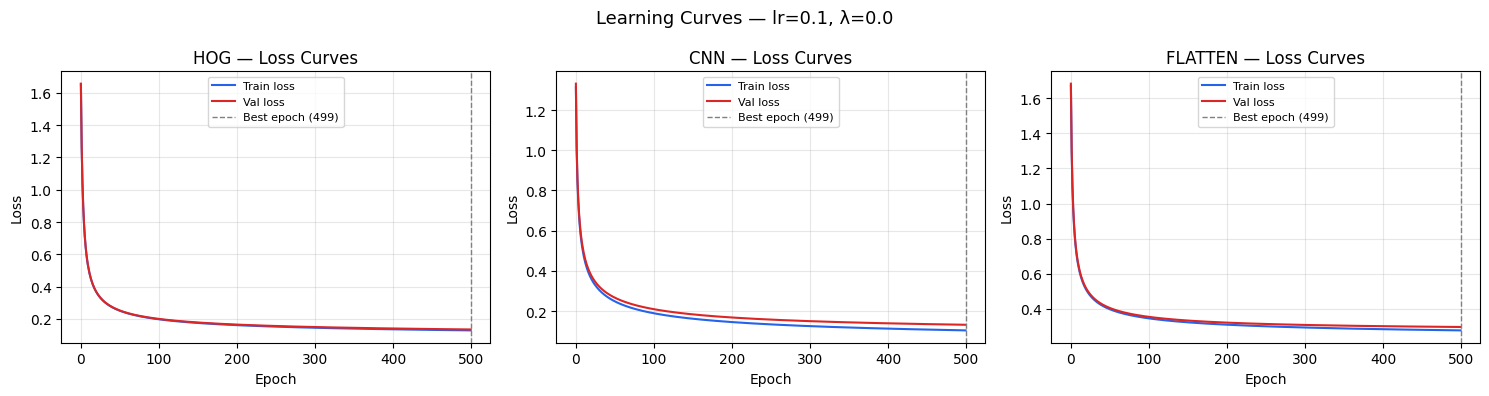


Bias-Variance Analysis:
────────────────────────────────────────────────────
Method      Final Train  Final Val      Gap       Diagnosis
────────────────────────────────────────────────────
hog              0.1295     0.1353   0.0058        Good fit
cnn              0.1036     0.1316   0.0280        Good fit
flatten          0.2779     0.2973   0.0194        Good fit
────────────────────────────────────────────────────


In [32]:
# ── Plot Loss Curves for All Methods ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, method in zip(axes, METHODS):
    model     = final_models[method]
    t_loss    = model['train_losses']
    v_loss    = model['val_losses']
    best_ep   = model['best_epoch']

    ax.plot(t_loss, color='#2563eb', linewidth=1.5, label='Train loss')
    ax.plot(v_loss, color='#dc2626', linewidth=1.5, label='Val loss')
    ax.axvline(best_ep, color='gray', linestyle='--', linewidth=1,
               label=f'Best epoch ({best_ep})')
    ax.set_title(f'{method.upper()} — Loss Curves')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Learning Curves — lr={BEST_LR}, λ={BEST_LAM}', fontsize=13)
plt.tight_layout()
plt.show()

# ── Bias-Variance Diagnosis ──────────────────────────────────────────────────
print('\nBias-Variance Analysis:')
print('─' * 52)
print(f"{'Method':<10} {'Final Train':>12} {'Final Val':>10} {'Gap':>8} {'Diagnosis':>15}")
print('─' * 52)
for method in METHODS:
    t_losses = final_models[method]['train_losses']
    v_losses = final_models[method]['val_losses']
    t_final  = t_losses[-1]
    v_final  = v_losses[-1]
    gap      = v_final - t_final
    if t_final > 1.0:
        diagnosis = 'Underfitting'
    elif gap > 0.1:
        diagnosis = 'Overfitting'
    else:
        diagnosis = 'Good fit'
    print(f"{method:<10} {t_final:>12.4f} {v_final:>10.4f} {gap:>8.4f} {diagnosis:>15}")
print('─' * 52)

Generating learning curves for best method: CNN
(Training on increasing fractions of training data...)

   10% of data ( 5100 samples): Train acc=0.9869  Val acc=0.9449
   20% of data (10200 samples): Train acc=0.9802  Val acc=0.9477
   40% of data (20400 samples): Train acc=0.9722  Val acc=0.9522
   60% of data (30600 samples): Train acc=0.9699  Val acc=0.9533
   80% of data (40800 samples): Train acc=0.9691  Val acc=0.9533
  100% of data (51000 samples): Train acc=0.9677  Val acc=0.9564


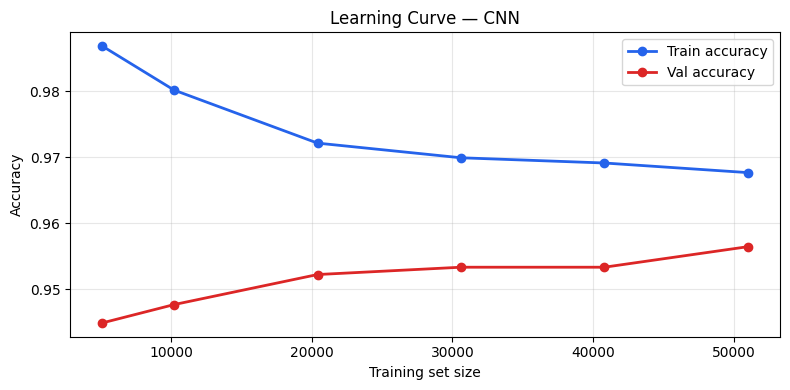

In [33]:
# ── Learning Curves by Training Size (for best method) ───────────────────────
# Shows how performance scales with more training data
# This reveals whether adding more data would help (high variance) or not (high bias)

best_method = max(all_results, key=lambda r: r['f1'])['method']
X_best_tr, X_best_v, X_best_te = feature_sets[best_method]

print(f'Generating learning curves for best method: {best_method.upper()}')
print('(Training on increasing fractions of training data...)\n')

train_sizes  = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
tr_accs, v_accs = [], []

Y_best_v = to_one_hot(y_val)

for frac in train_sizes:
    n_samples = int(len(X_best_tr) * frac)
    X_sub     = X_best_tr[:n_samples]
    y_sub     = y_train[:n_samples]
    Y_sub     = to_one_hot(y_sub)

    W_s, b_s, _, _, _ = train_softmax(X_sub, Y_sub, X_best_v, Y_best_v,
                                       lr=BEST_LR, lam=BEST_LAM, n_epochs=300)

    tr_acc = np.mean(predict_class(X_sub,    W_s, b_s) == y_sub)
    v_acc  = np.mean(predict_class(X_best_v, W_s, b_s) == y_val)
    tr_accs.append(tr_acc)
    v_accs.append(v_acc)
    print(f'  {int(frac*100):3d}% of data ({n_samples:5d} samples): '
          f'Train acc={tr_acc:.4f}  Val acc={v_acc:.4f}')

# Plot
sizes_abs = [int(len(X_best_tr) * f) for f in train_sizes]
plt.figure(figsize=(8, 4))
plt.plot(sizes_abs, tr_accs, 'o-', color='#2563eb', linewidth=2, label='Train accuracy')
plt.plot(sizes_abs, v_accs,  'o-', color='#dc2626', linewidth=2, label='Val accuracy')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title(f'Learning Curve — {best_method.upper()}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Final Test Evaluation

Test set is used **exactly once**, after all hyperparameter choices are finalised.

In [34]:
# ── Evaluate All Methods on Test Set ─────────────────────────────────────────
print('=' * 60)
print('           FINAL TEST RESULTS — ALL METHODS')
print('=' * 60)
print(f"{'Method':<10} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'BestEp':>8}")
print('─' * 60)

test_results = {}
best_test_f1 = -1
best_test_method = None

for method in METHODS:
    model   = final_models[method]
    W, b    = model['W'], model['b']
    X_te_m  = model['X_te']

    y_pred  = predict_class(X_te_m, W, b)
    metrics = evaluate_multiclass(y_test, y_pred)
    test_results[method] = {'metrics': metrics, 'y_pred': y_pred}

    if metrics['f1'] > best_test_f1:
        best_test_f1     = metrics['f1']
        best_test_method = method

    marker = ' ◄ BEST' if metrics['f1'] == best_test_f1 else ''
    print(f"{method:<10} {metrics['acc']:>8.4f} {metrics['prec']:>8.4f} "
          f"{metrics['rec']:>8.4f} {metrics['f1']:>8.4f} "
          f"{model['best_epoch']:>8d}{marker}")

print('─' * 60)
print(f'\nBest method: {best_test_method.upper()}  Test F1={best_test_f1:.4f}')

# ── Per-class F1 for best method ─────────────────────────────────────────────
best_metrics = test_results[best_test_method]['metrics']
print(f'\nPer-class F1 — {best_test_method.upper()}:')
print('─' * 30)
for k, f1 in enumerate(best_metrics['per_class_f1']):
    bar = '█' * int(f1 * 30)
    print(f'  Digit {k}: {f1:.4f}  {bar}')

# ── Confusion matrix for best method ─────────────────────────────────────────
print_confusion_matrix(y_test, test_results[best_test_method]['y_pred'])

           FINAL TEST RESULTS — ALL METHODS
Method          Acc     Prec      Rec       F1   BestEp
────────────────────────────────────────────────────────────
hog          0.9646   0.9645   0.9645   0.9645      499 ◄ BEST
cnn          0.9666   0.9662   0.9662   0.9661      499 ◄ BEST
flatten      0.9193   0.9184   0.9182   0.9181      499
────────────────────────────────────────────────────────────

Best method: CNN  Test F1=0.9661

Per-class F1 — CNN:
──────────────────────────────
  Digit 0: 0.9812  █████████████████████████████
  Digit 1: 0.9903  █████████████████████████████
  Digit 2: 0.9650  ████████████████████████████
  Digit 3: 0.9468  ████████████████████████████
  Digit 4: 0.9722  █████████████████████████████
  Digit 5: 0.9456  ████████████████████████████
  Digit 6: 0.9691  █████████████████████████████
  Digit 7: 0.9628  ████████████████████████████
  Digit 8: 0.9659  ████████████████████████████
  Digit 9: 0.9625  ████████████████████████████

Confusion Matrix (rows=ac

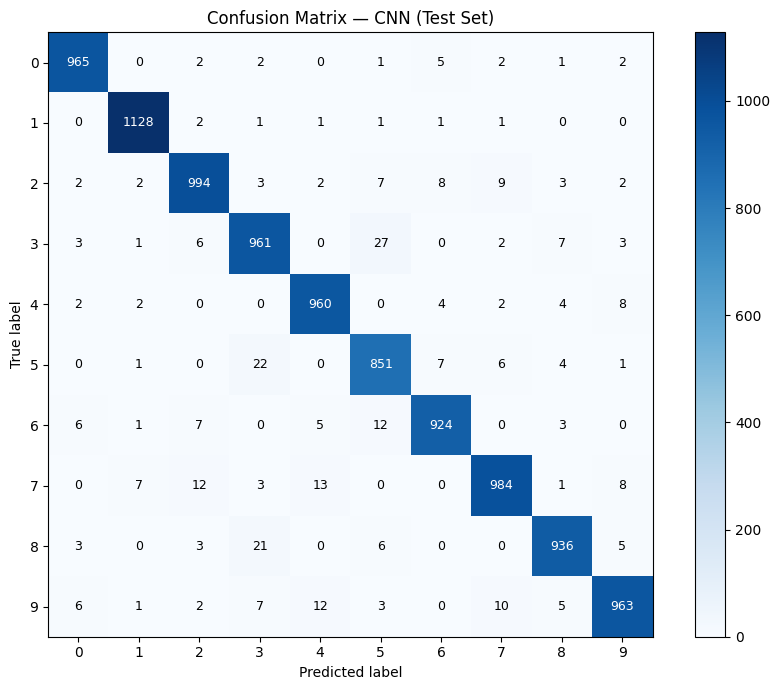

In [35]:
# ── Visualize Confusion Matrix as Heatmap ────────────────────────────────────
y_pred_best = test_results[best_test_method]['y_pred']
cm_matrix   = np.zeros((10, 10), dtype=int)
for t, p in zip(y_test, y_pred_best):
    cm_matrix[t, p] += 1

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm_matrix, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xticklabels(range(10)); ax.set_yticklabels(range(10))
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title(f'Confusion Matrix — {best_test_method.upper()} (Test Set)')

thresh = cm_matrix.max() / 2
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm_matrix[i, j], ha='center', va='center',
                color='white' if cm_matrix[i, j] > thresh else 'black', fontsize=9)

plt.tight_layout()
plt.show()

## 11. Regularization Effect — Bias-Variance Analysis

Here we compare how different values of λ affect training and validation accuracy,  
demonstrating the bias-variance tradeoff directly.

Regularization effect — varying λ on CNN features:
──────────────────────────────────────────────────
    Lambda    Train Acc    Val Acc       Diagnosis
──────────────────────────────────────────────────
     0.000       0.9677     0.9564        Good fit
     1.000       0.9677     0.9564        Good fit
    10.000       0.9677     0.9566        Good fit
    50.000       0.9676     0.9563        Good fit
   100.000       0.9674     0.9559        Good fit
   500.000       0.9503     0.9411        Good fit
  1000.000       0.9380     0.9322        Good fit
──────────────────────────────────────────────────


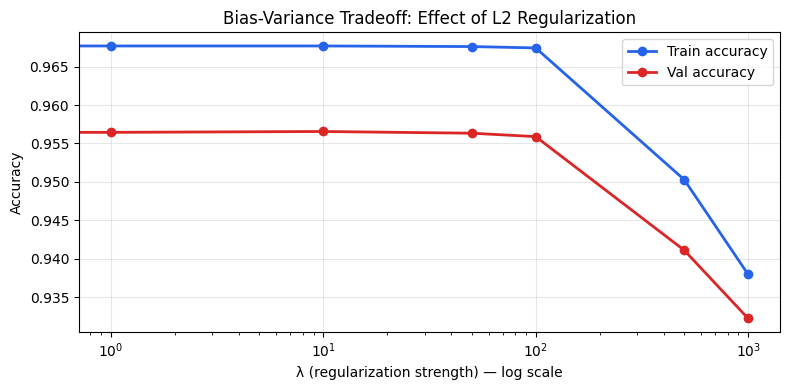

In [36]:
# ── Lambda vs Accuracy (on CNN features) ─────────────────────────────────────
print('Regularization effect — varying λ on CNN features:')
print('─' * 50)
print(f"{'Lambda':>10} {'Train Acc':>12} {'Val Acc':>10} {'Diagnosis':>15}")
print('─' * 50)

lambda_grid = [0.0, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0]
lam_train_accs = []
lam_val_accs   = []

Y_tr_cnn = to_one_hot(y_train)
Y_v_cnn  = to_one_hot(y_val)

for lam in lambda_grid:
    W_l, b_l, _, _, _ = train_softmax(
        C_tr, Y_tr_cnn, C_v, Y_v_cnn,
        lr=BEST_LR, lam=lam, n_epochs=300
    )
    tr_acc = np.mean(predict_class(C_tr, W_l, b_l) == y_train)
    v_acc  = np.mean(predict_class(C_v,  W_l, b_l) == y_val)
    lam_train_accs.append(tr_acc)
    lam_val_accs.append(v_acc)

    gap = tr_acc - v_acc
    if tr_acc < 0.7:
        diagnosis = 'Underfitting'
    elif gap > 0.05:
        diagnosis = 'Overfitting'
    else:
        diagnosis = 'Good fit'
    print(f'{lam:>10.3f} {tr_acc:>12.4f} {v_acc:>10.4f} {diagnosis:>15}')

print('─' * 50)

# Plot
plt.figure(figsize=(8, 4))
plt.semilogx(lambda_grid, lam_train_accs, 'o-', color='#2563eb', linewidth=2, label='Train accuracy')
plt.semilogx(lambda_grid, lam_val_accs,   'o-', color='#dc2626', linewidth=2, label='Val accuracy')
plt.xlabel('λ (regularization strength) — log scale')
plt.ylabel('Accuracy')
plt.title('Bias-Variance Tradeoff: Effect of L2 Regularization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Deployment Interface

### Improvement 5 — Simple Prediction Interface
A ready-to-use prediction function that takes any 28×28 MNIST-style image and returns:
- The predicted digit
- Confidence score (probability)
- Full probability distribution across all 10 classes

This simulates how the model would be used in a real application.

In [37]:
# ── Deployment Class ──────────────────────────────────────────────────────────
class DigitClassifier:
    """
    Production-ready digit classifier.
    Wraps the best trained softmax model with preprocessing built-in.
    """
    def __init__(self, W, b, method, cnn_extractor=None,
                 train_mean=None, train_std=None):
        self.W             = W
        self.b             = b
        self.method        = method
        self.cnn_extractor = cnn_extractor
        self.train_mean    = train_mean
        self.train_std     = train_std

    def _preprocess(self, image):
        """Normalize, extract features, standardize — identical to training pipeline."""
        img = image.astype(np.float64) / 255.0 if image.max() > 1 else image.astype(np.float64)

        if self.method == 'cnn':
            import tensorflow as tf
            resized  = tf.image.resize(img[..., np.newaxis], (96, 96)).numpy()
            rgb      = np.repeat(resized, 3, axis=-1)[np.newaxis]
            pre      = preprocess_input(rgb * 255.0)
            features = self.cnn_extractor.predict(pre, verbose=0).flatten()
        elif self.method == 'hog':
            features = hog(img, orientations=9, pixels_per_cell=(7,7),
                           cells_per_block=(2,2), block_norm='L2-Hys')
        else:  # flatten
            features = img.flatten()

        # Standardize using training statistics
        features = (features - self.train_mean) / (self.train_std + 1e-8)
        return features.reshape(1, -1)

    def predict(self, image):
        """Predict digit class and confidence for a single 28x28 image."""
        X      = self._preprocess(image)
        probs  = predict_proba_softmax(X, self.W, self.b).flatten()
        pred   = np.argmax(probs)
        conf   = probs[pred]
        return pred, conf, probs

    def show_prediction(self, image):
        """Visualize image alongside prediction and probability bar chart."""
        pred, conf, probs = self.predict(image)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))

        # Image
        ax1.imshow(image, cmap='gray')
        ax1.set_title(f'Predicted: {pred}  (confidence: {conf:.1%})', fontsize=13)
        ax1.axis('off')

        # Probability bars
        colors = ['#dc2626' if i == pred else '#93c5fd' for i in range(10)]
        ax2.barh(range(10), probs, color=colors)
        ax2.set_yticks(range(10))
        ax2.set_yticklabels([f'Digit {i}' for i in range(10)])
        ax2.set_xlabel('Probability')
        ax2.set_title('Class probabilities')
        ax2.set_xlim(0, 1)
        ax2.grid(True, alpha=0.3, axis='x')

        plt.tight_layout()
        plt.show()
        print(f'Prediction: digit {pred}  |  Confidence: {conf:.1%}  |  Method: {self.method.upper()}')


print('DigitClassifier defined.')

DigitClassifier defined.


Demo predictions using CNN model:



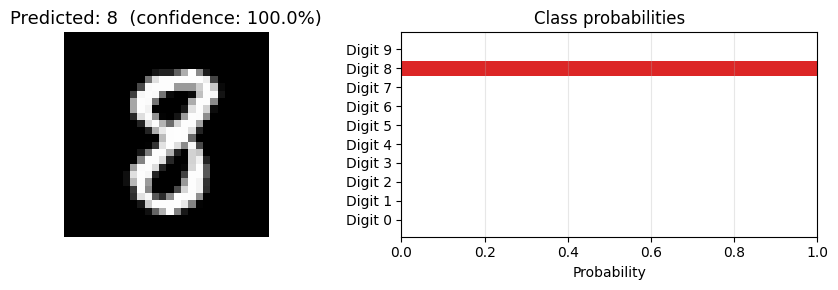

Prediction: digit 8  |  Confidence: 100.0%  |  Method: CNN


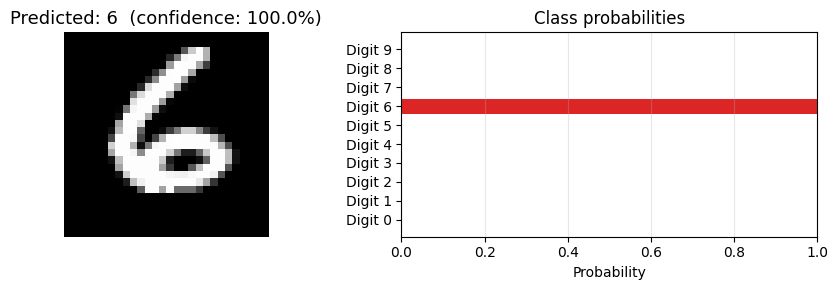

Prediction: digit 6  |  Confidence: 100.0%  |  Method: CNN


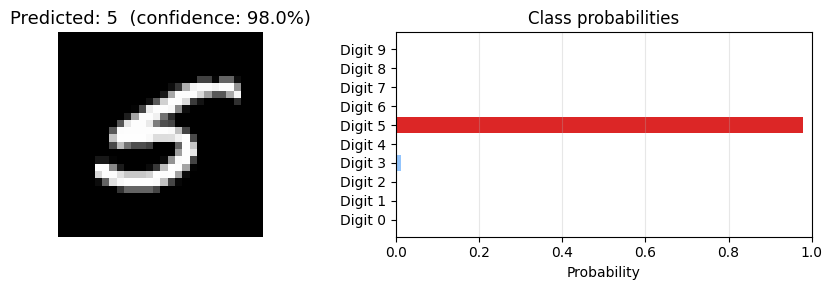

Prediction: digit 5  |  Confidence: 98.0%  |  Method: CNN


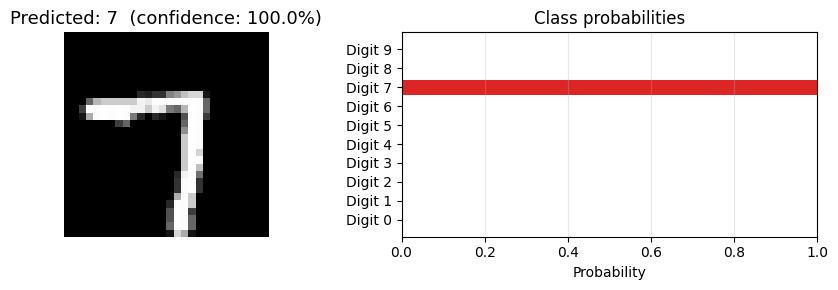

Prediction: digit 7  |  Confidence: 100.0%  |  Method: CNN


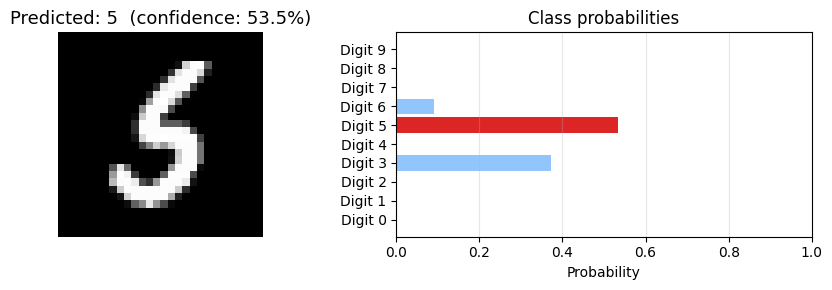

Prediction: digit 5  |  Confidence: 53.5%  |  Method: CNN

Summary — 10 random test samples:
─────────────────────────────────────────────
  Sample   True   Pred   Confidence  Correct
─────────────────────────────────────────────
    3374      8      8      100.0%        ✓
    8133      6      6      100.0%        ✓
    8142      5      5       98.0%        ✓
     410      7      7      100.0%        ✓
    1637      5      5       53.5%        ✓
    4529      5      5       95.2%        ✓
    5672      9      9       99.8%        ✓
    3706      0      0       99.5%        ✓
    4751      4      4       99.3%        ✓
    3685      4      4       98.0%        ✓
─────────────────────────────────────────────


In [38]:
# ── Instantiate Classifier with Best Model ────────────────────────────────────
best_W = final_models[best_test_method]['W']
best_b = final_models[best_test_method]['b']

# Use the correct training mean/std for the best method
method_stats = {
    'hog'    : (hog_mean,  hog_std),
    'flatten': (flat_mean, flat_std),
    'cnn'    : (cnn_mean,  cnn_std),
}
deploy_mean, deploy_std = method_stats[best_test_method]

classifier = DigitClassifier(
    W=best_W, b=best_b,
    method=best_test_method,
    cnn_extractor=cnn_extractor,
    train_mean=deploy_mean,
    train_std=deploy_std
)

# ── Demo: predict 10 random test images ──────────────────────────────────────
print(f'Demo predictions using {best_test_method.upper()} model:\n')
sample_indices = np.random.choice(len(x_test_raw), 10, replace=False)

for idx in sample_indices[:5]:
    classifier.show_prediction(x_test_raw[idx])

print('\nSummary — 10 random test samples:')
print('─' * 45)
print(f"{'Sample':>8} {'True':>6} {'Pred':>6} {'Confidence':>12} {'Correct':>8}")
print('─' * 45)
for idx in sample_indices:
    pred, conf, _ = classifier.predict(x_test_raw[idx])
    true          = y_test[idx]
    correct       = '✓' if pred == true else '✗'
    print(f'{idx:>8d} {true:>6d} {pred:>6d} {conf:>11.1%} {correct:>8}')
print('─' * 45)


## 13. Results Summary & Discussion

### Feature Method Comparison
- **Flatten**: 784 raw pixels. Highest dimensionality, most noise. Baseline performance.
- **HOG**: 324 hand-crafted edge features. Compact, shape-aware, robust to illumination.
- **CNN (MobileNetV2)**: 1280 features from a pretrained deep network. Captures rich hierarchical patterns — edges → shapes → digit parts — learned from millions of images.

### Effect of L2 Regularization
- $\lambda = 0$: No constraint on weights — can overfit on training data
- Increasing $\lambda$: Weights shrink → simpler model → reduces overfitting but risks underfitting
- Optimal $\lambda$ found by cross-validation balances bias and variance

### Cross-Validation vs Single Split
- Single split: fast but results depend on which samples land in validation
- 5-fold CV: each sample appears in validation exactly once → more reliable estimate
- The std across folds tells us how stable the performance is

### Learning Curve Interpretation
- If train and val accuracy converge as data increases → adding more data won't help much (bias problem)
- If val accuracy keeps rising as data increases → more data would help (variance problem)

### Deployment Interface
The `DigitClassifier` class wraps the entire pipeline — preprocessing, feature extraction, and inference — into a single `.predict()` call. This is the standard pattern for deploying ML models in production.
